In [1]:
import rasterio
import rasterio.plot
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
raster_path = "https://github.com/opengeos/datasets/releases/download/raster/dem_90m.tif"
src = rasterio.open(raster_path)
print(src)

print("Raster metadata:")
for key, value in src.meta.items():
    print(f"{key}: {value}")

<open DatasetReader name='https://github.com/opengeos/datasets/releases/download/raster/dem_90m.tif' mode='r'>
Raster metadata:
driver: GTiff
dtype: int16
nodata: None
width: 4269
height: 3113
count: 1
crs: EPSG:3857
transform: | 90.00, 0.00,-13442488.34|
| 0.00,-90.00, 4668371.58|
| 0.00, 0.00, 1.00|


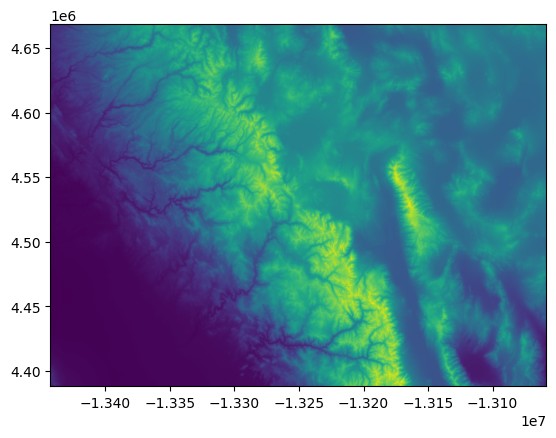

<Axes: >

In [3]:
rasterio.plot.show(src)

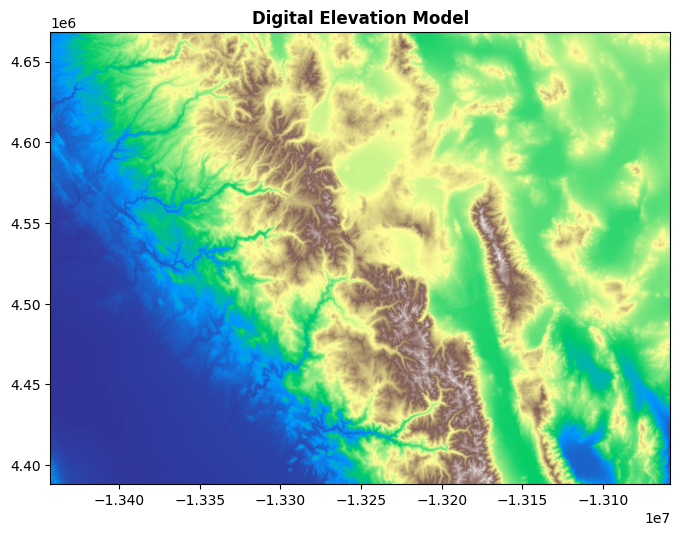

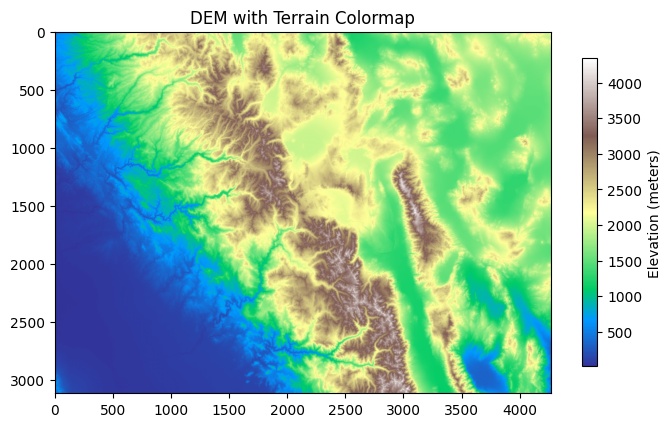

In [4]:
fig, ax= plt.subplots(figsize=(8, 8))
rasterio.plot.show(src, cmap="terrain", ax=ax, title="Digital Elevation Model")
elev_band = src.read(1)
plt.figure(figsize=(8, 8))
plt.imshow(elev_band, cmap="terrain")
plt.colorbar(label="Elevation (meters)", shrink=0.5)
plt.title("DEM with Terrain Colormap")
plt.show()

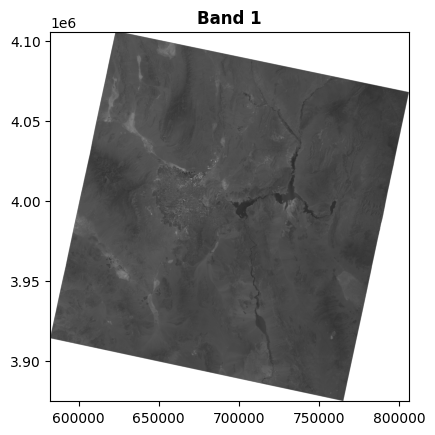

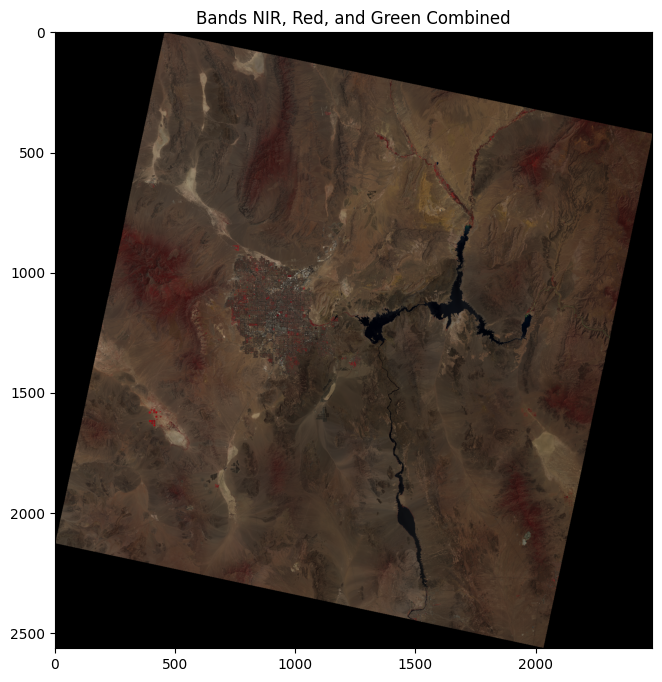

In [5]:
raster_path = "https://github.com/opengeos/datasets/releases/download/raster/LC09_039035_20240708_90m.tif"
src = rasterio.open(raster_path)
rasterio.plot.show((src, 1), cmap="gray", title="Band 1")

nir_band = src.read(5)
red_band = src.read(4)
green_band = src.read(3)

rgb = np.dstack((nir_band, red_band, green_band)).clip(0, 1)

plt.figure(figsize=(8,8))
plt.imshow(rgb)
plt.title("Bands NIR, Red, and Green Combined")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

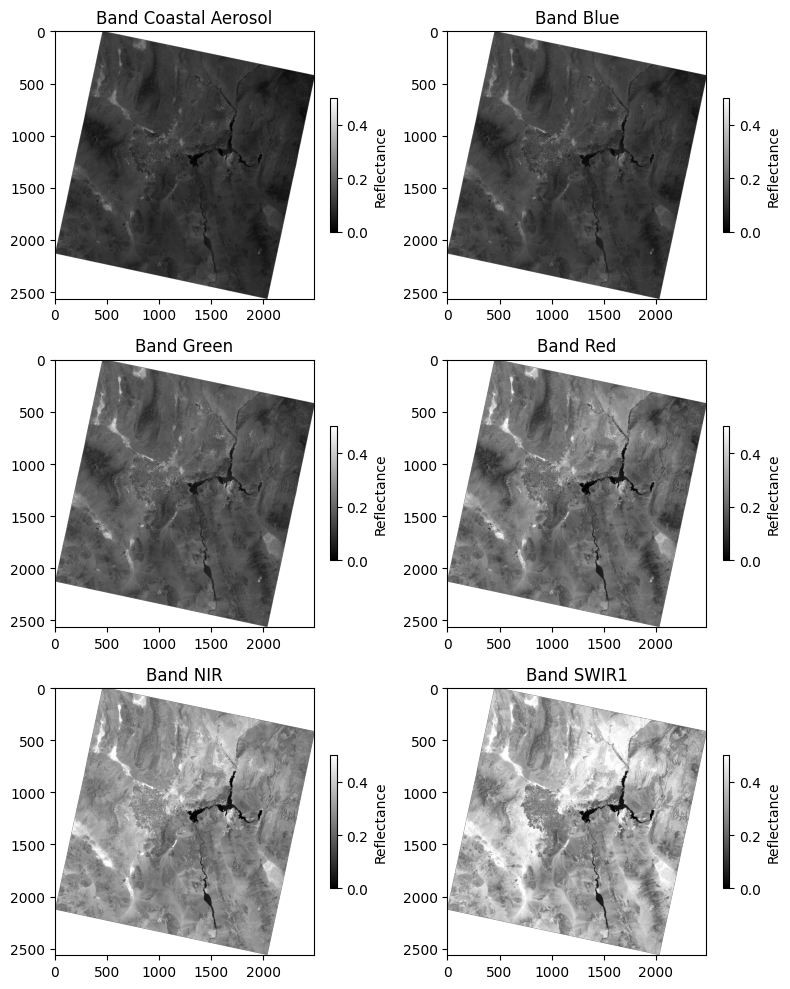

In [6]:
band_names = ["Coastal Aerosol", "Blue", "Green", "Red", "NIR", "SWIR1", "SWIR2"]

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(8, 10))
axes = axes.flatten()

for band in range (1, src.count):
    data = src.read(band)
    ax = axes[band - 1]
    im = ax.imshow(data, cmap="gray", vmin=0, vmax=0.5)
    ax.set_title(f"Band {band_names[band-1]}")
    fig.colorbar(im, ax=ax, label="Reflectance", shrink=0.5)

plt.tight_layout()
plt.show

<Axes: title={'center': 'DEM with Vector Overlay'}>

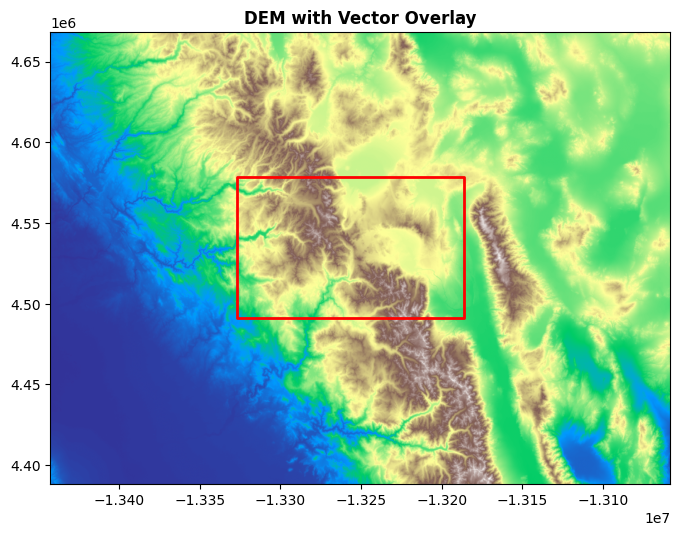

In [7]:
raster_path = (
"https://github.com/opengeos/datasets/releases/download/raster/dem_90m.tif"
)
src = rasterio.open(raster_path)

vector_path = (
"https://github.com/opengeos/datasets/releases/download/places/dem_bounds.geojson"
)
gdf = gpd.read_file(vector_path)
gdf = gdf.to_crs(src.crs)

fig, ax = plt.subplots(figsize=(8, 8))
rasterio.plot.show(src, cmap="terrain", ax=ax, title="DEM with Vector Overlay")
gdf.plot(ax=ax, edgecolor="red", facecolor="None", linewidth=2)

<positron-console-cell-8>:1: RuntimeWarning: invalid value encountered in subtract


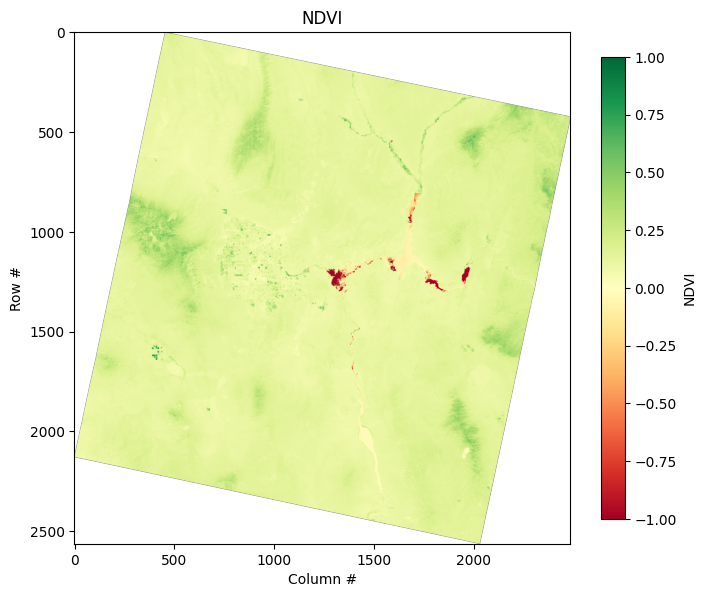

{'driver': 'GTiff', 'dtype': 'float32', 'nodata': None, 'width': 4269, 'height': 3113, 'count': 1, 'crs': CRS.from_wkt('PROJCS["WGS 84 / Pseudo-Mercator",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Mercator_1SP"],PARAMETER["central_meridian",0],PARAMETER["scale_factor",1],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],EXTENSION["PROJ4","+proj=merc +a=6378137 +b=6378137 +lat_ts=0 +lon_0=0 +x_0=0 +y_0=0 +k=1 +units=m +nadgrids=@null +wktext +no_defs"],AUTHORITY["EPSG","3857"]]'), 'transform': Affine(90.0, 0.0, -13442488.3428,
       0.0, -89.99579177642138, 4668371.5775), 'blockxsize': 512, 'blockysize': 512, 'tiled': True, 'compress': 'lzw', 'interleave': 'band'}
Raster 

In [8]:
ndvi = (nir_band - red_band) / (nir_band + red_band)
ndvi = ndvi.clip(-1, 1)

plt.figure(figsize=(8, 8))
plt.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(label="NDVI", shrink=0.75)
plt.title("NDVI")
plt.xlabel("Column #")
plt.ylabel("Row #")
plt.show()

with rasterio.open(raster_path):
    profile = src.profile
profile.update(dtype=rasterio.float32, count=1, compress="lzw")
print(profile)

output_raster_path = "ndvi.tif"

with rasterio.open(output_raster_path, "w", **profile) as dst:
    dst.write(ndvi, 1)
print(f"Raster data has been written to {output_raster_path}")

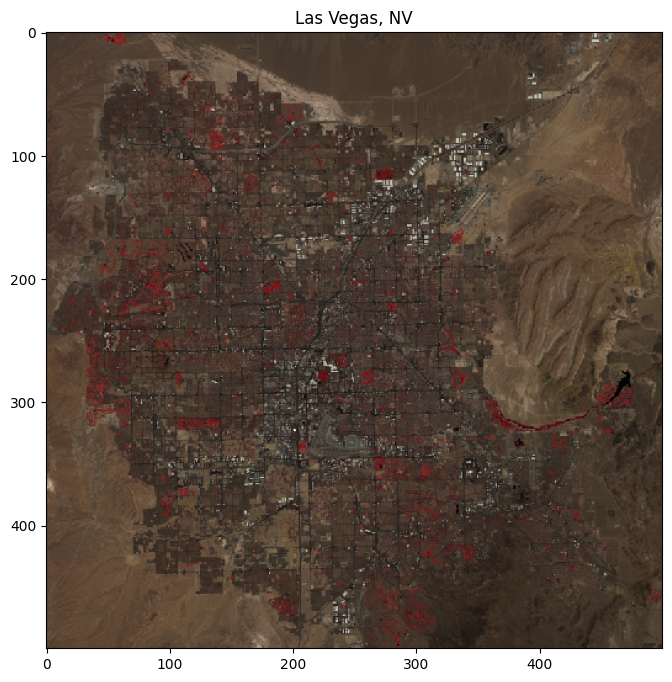

In [9]:
raster_path = "https://github.com/opengeos/datasets/releases/download/raster/LC09_039035_20240708_90m.tif"
src = rasterio.open(raster_path)
data = src.read()
subset = data[:, 900:1400, 700:1200].clip(0, 1)
rgb_subset = np.dstack((subset[4], subset[3], subset[2]))
rgb_subset.shape

plt.figure(figsize=(8, 8))
plt.imshow(rgb_subset)
plt.title("Las Vegas, NV")
plt.show()

In [10]:
from rasterio.windows import Window
from rasterio.transform import from_bounds

window = Window(col_off = 700, row_off=900, width=500, height=500)

window_bounds = rasterio.windows.bounds(window, src.transform)
new_transform = from_bounds(*window_bounds, window.width, window.height)

with rasterio.open(
    "las_vegas.tif",
    "w",
    driver="GTiff",
    height=subset.shape[1],
    width=subset.shape[2],
    count=subset.shape[0],
    dtype=subset.dtype,
    crs=src.crs,
    transform=new_transform,
    compress="lzw"
) as dst:
    dst.write(subset)


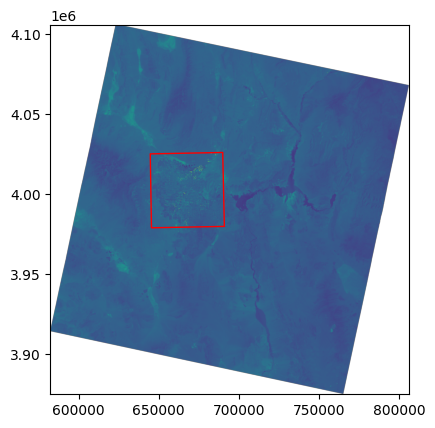

In [11]:
import fiona
import rasterio.mask

geojson_path = "https://github.com/opengeos/datasets/releases/download/places/las_vegas_bounds_utm.geojson"
bounds = gpd.read_file(geojson_path)

fig, ax = plt.subplots()
rasterio.plot.show(src, ax=ax)
bounds.plot(ax=ax, edgecolor="red", facecolor="none")

with fiona.open(geojson_path, "r") as f:
    shapes = [feature["geometry"]for feature in f]
out_image, out_transform = rasterio.mask.mask(src, shapes, crop=True)

out_meta = src.meta
out_meta.update(
    {
        "driver": "GTiff",
        "height": out_image.shape[1],
        "width": out_image.shape[2],
        "transform": out_transform,
    }
)
with rasterio.open("las_vegas_clip.tif", "w", **out_meta) as dst:
    dst.write(out_image)

In [16]:
url =  "https://github.com/opengeos/datasets/releases/download/raster/dem_90m.tif"
src_sb = rasterio.open(url)
data_sb = src.read()

url = "https://github.com/opengeos/datasets/releases/download/raster/cog.tif"
src_mb = rasterio.open(url)
data_mb = src.read()

print(src_sb.meta.items())

dict_items([('driver', 'GTiff'), ('dtype', 'int16'), ('nodata', None), ('width', 4269), ('height', 3113), ('count', 1), ('crs', CRS.from_wkt('PROJCS["WGS 84 / Pseudo-Mercator",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Mercator_1SP"],PARAMETER["central_meridian",0],PARAMETER["scale_factor",1],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],EXTENSION["PROJ4","+proj=merc +a=6378137 +b=6378137 +lat_ts=0 +lon_0=0 +x_0=0 +y_0=0 +k=1 +units=m +nadgrids=@null +wktext +no_defs"],AUTHORITY["EPSG","3857"]]')), ('transform', Affine(90.0, 0.0, -13442488.3428,
       0.0, -89.99579177642138, 4668371.5775))])
